# Project2 - Exploratory Data Analysis (EDA)

This notebook explores the synthetic dataset generated for the project2 of IA.  
The dataset contains patient health indicators used to predict risk of **Diabetes** and **Hypertension**.

**Sections:**
1. Dataset Overview
2. Variable Distributions
3. Class Balance
4. Correlations with Targets

In [9]:
import pandas 
import numpy 
import matplotlib.pyplot as plt
import seaborn 

seaborn.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pandas.read_csv('data.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


---
## Dataset Overview

In [2]:
df.head(15) #first 15 elem of the dataset

,age,sex,imc,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,36,0,26.3,100,70,222,0,1,0,0,0,0
1,52,0,24.6,138,108,213,1,1,1,0,0,0
2,52,0,28.7,118,70,164,0,1,0,0,0,0
3,65,1,19.7,147,72,229,1,2,0,0,0,1
4,31,1,26.0,107,124,160,0,0,0,0,0,0
5,43,1,35.7,114,106,242,0,0,1,1,1,1
6,18,1,29.7,150,115,196,0,2,0,0,0,0
7,37,1,26.4,131,147,198,0,1,0,1,0,1
8,50,1,26.5,92,130,232,0,0,0,1,0,1
9,31,1,18.9,130,153,238,0,1,0,0,0,0


In [ ]:
print('Column Types')
print(df.dtypes)
print()
print('Missing Values')
print(df.isnull().sum())
print()

Column Types
age                              int64
sex                              int64
imc                            float64
systolic_pressure                int64
glucose                          int64
cholesterol                      int64
smoking                          int64
physical_activity                int64
family_history_diabetes          int64
family_history_hypertension      int64
diabetes_risk                    int64
hypertension_risk                int64
dtype: object

Missing Values
age                            0
sex                            0
imc                            0
systolic_pressure              0
glucose                        0
cholesterol                    0
smoking                        0
physical_activity              0
family_history_diabetes        0
family_history_hypertension    0
diabetes_risk                  0
hypertension_risk              0
dtype: int64



In [10]:
df.describe().round(2) #statistical summary of vars

,age,sex,bmi,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
count,852.00,852.0,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00,852.00
mean,45.07,0.5,26.18,126.47,101.43,199.82,0.23,0.82,0.32,0.35,0.21,0.37
std,15.18,0.5,5.62,21.04,28.74,37.31,0.42,0.75,0.47,0.48,0.41,0.48
min,18.00,0.0,16.00,90.00,70.00,130.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,34.00,0.0,22.10,111.00,73.00,174.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,45.00,0.5,26.20,127.00,97.00,199.00,0.00,1.00,0.00,0.00,0.00,0.00
75%,56.00,1.0,30.10,141.00,122.00,225.00,0.00,1.00,1.00,1.00,0.00,1.00
max,80.00,1.0,42.20,200.00,202.00,317.00,1.00,2.00,1.00,1.00,1.00,1.00


---
## Variable Distributions

### Numeric Variables

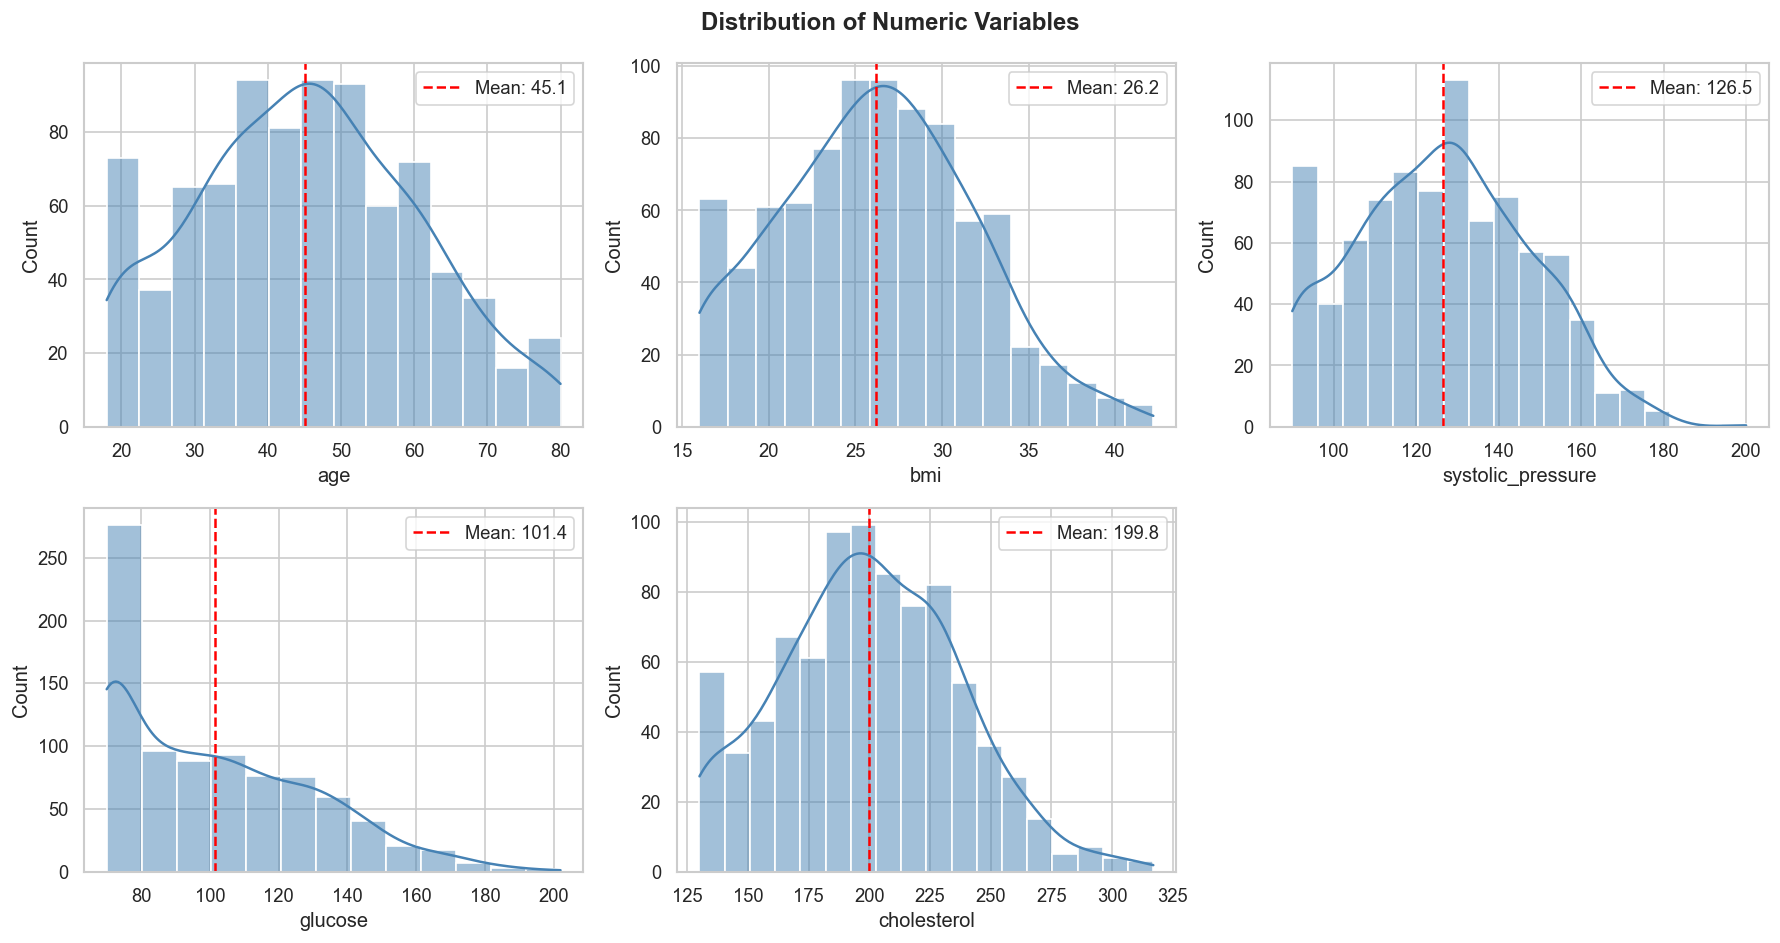

In [37]:
numeric_cols = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol']
labels = ['Age (years)', 'BMI (kg/m²)', 'Systolic Pressure (mmHg)', 'Glucose (mg/dL)', 'Cholesterol (mg/dL)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_cols, labels)):
    seaborn.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    
    mean_val = df[col].mean() #cals the mean of each graph
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

axes[-1].axis('off')  #hide last spot since its only 5 graphs
fig.suptitle('Distribution of Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### Binary and Ordinal Variables
Frequency counts for categorical features.

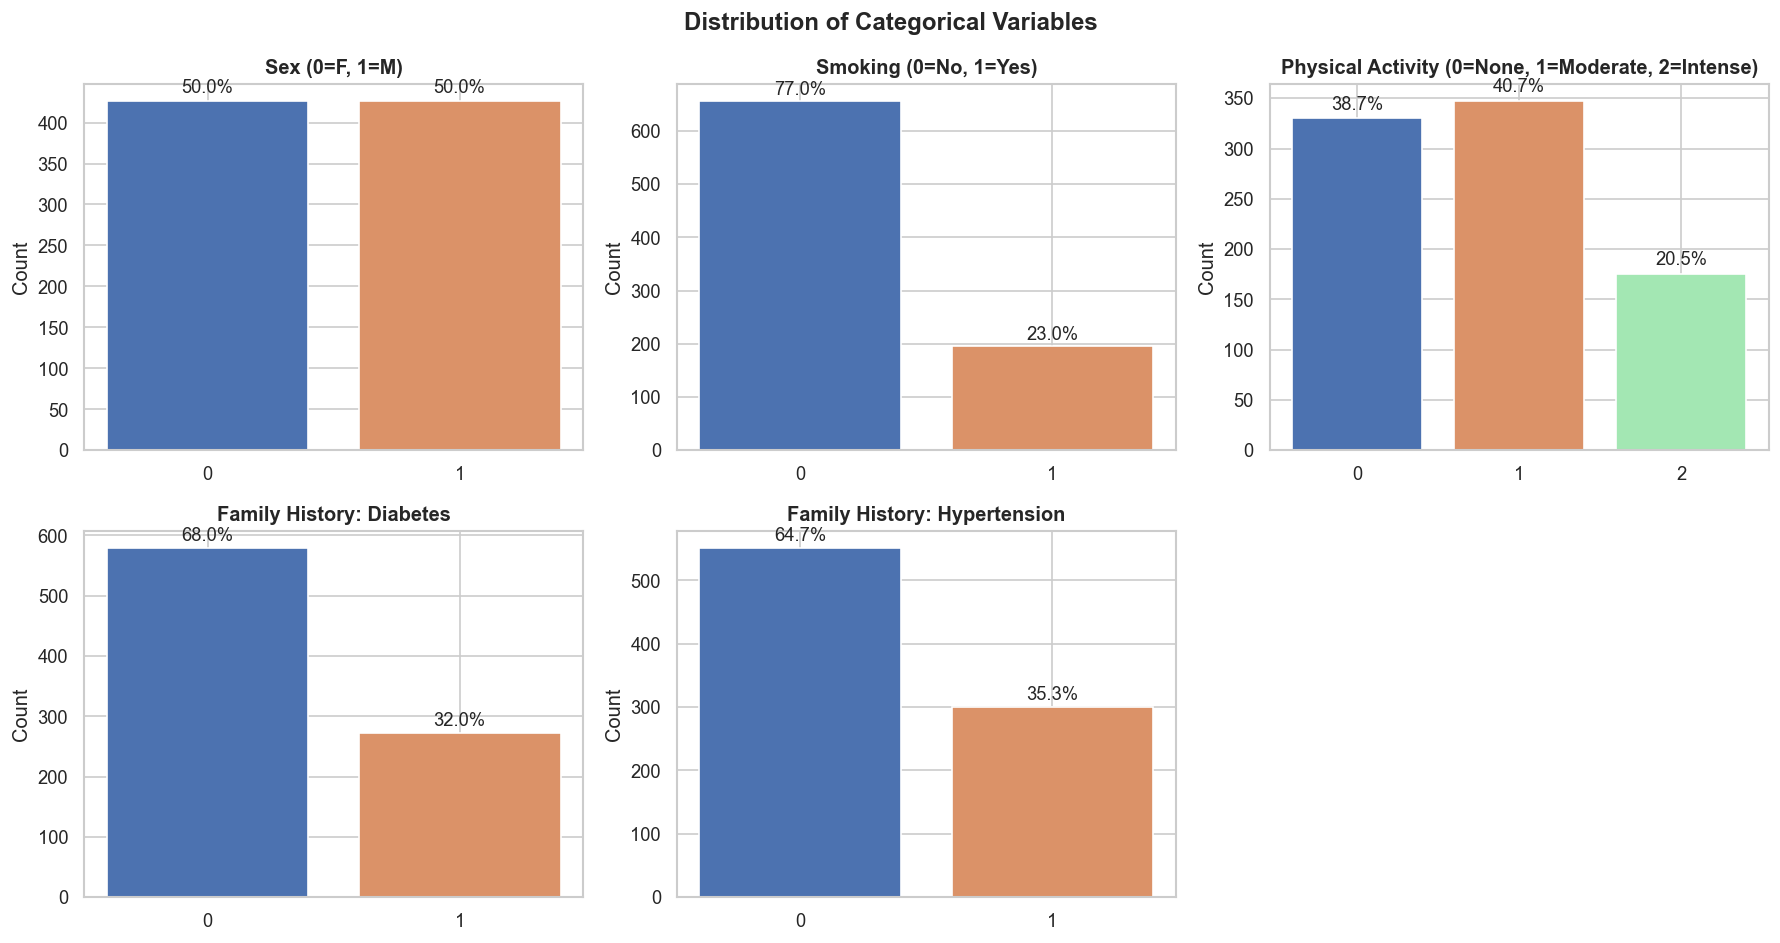

In [47]:
cat_cols = ['sex', 'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']
cat_labels = ['Sex (0=F, 1=M)', 'Smoking (0=No, 1=Yes)', 'Physical Activity (0=None, 1=Moderate, 2=Intense)',
              'Family History: Diabetes', 'Family History: Hypertension']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#4C72B0', "#DB9268", "#A3E7B3"]

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    counts = df[col].value_counts().sort_index() #count how many times each value apears
    
    bars = axes[i].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
    
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    for bar in bars:
        height = bar.get_height()
        percentage = height / len(df) * 100
        
        axes[i].text(bar.get_x() + bar.get_width()/2, height + 5, f'{percentage:.1f}%',ha='center', va='bottom', fontsize=11)

axes[-1].axis('off')
fig.suptitle('Distribution of Categorical Variables', fontweight='bold')
plt.tight_layout()
plt.show()